<div style="background:linear-gradient(135deg,#022c22 0%,#047857 55%,#10b981 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#d1fae5;font-weight:700;text-transform:uppercase">Chapter 101 · Logistic Regression Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Logistic Regression in Action</div>
  <div style="font-size:15px;color:#f0fdf4;max-width:740px;line-height:1.6">A complete classification project in 12 steps: from a messy churn export to a cleaned, encoded, fitted, validated, and threshold-tuned logistic model, with odds ratios read as retention actions.</div>
  <div style="margin-top:16px;font-size:13px;color:#d1fae5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Predicting Customer Churn: a logistic-regression case study
The classification counterpart to the house-price study, same **12-step method**, but the outcome is now yes/no: will a customer leave? We take a messy telecom export (mixed target labels, categories in every spelling, charges stored as text with blanks, duplicates, and class imbalance) all the way to a validated, threshold-tuned classifier, and explain every table and picture.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#059669"; DEEP="#047857"; LIGHT="#6ee7b7"; EM="#059669"; EMDEEP="#047857"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf, statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, classification_report, RocCurveDisplay, recall_score, precision_score)
from sklearn.model_selection import cross_val_score; from sklearn.linear_model import LogisticRegression
pd.set_option('display.max_columns', 40)

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 1 &#183; DEFINE THE OBJECTIVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Who leaves, and why?</div>
<div style="color:#4a5578;margin-top:6px">A churn model is only useful if it feeds a retention decision.</div>
</div>

**Objective.** Predict which customers will **churn** (cancel service), and identify the factors that drive churn, so a retention team can act *before* they leave.

**For whom / the decision.** The retention team will call or offer a discount to high-risk customers. That means we care most about **recall** (catching churners), and the **threshold** is a business choice about the cost of an offer versus the cost of losing a customer.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 2 &#183; COLLECT THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A telecom systems export</div>
<div style="color:#4a5578;margin-top:6px">Same reader menu as any project (CSV / Excel / SQL / API / scrape); ours is a CSV.</div>
</div>

Customer data usually lives in a billing database or CRM. The pandas readers are the same as always: `pd.read_sql(...)` from the warehouse, `pd.read_csv(...)` from an export, `pd.json_normalize(requests.get(...).json())` from a REST API. Ours is a CSV export:

In [3]:
try:
    raw = pd.read_csv('../../data/telecom_churn.csv')
except FileNotFoundError:
    raw = pd.read_csv(BASE + 'telecom_churn.csv')
print(raw.shape); raw.head(4)

(775, 11)


,customer_id,gender,senior_citizen,partner,tenure_months,contract,internet_service,payment_method,monthly_charges,total_charges,churn
0,C7344,F,0,No,8,One year,Fiber optic,Bank transfer,82.22,630.62,Yes
1,C7431,Female,0,Yes,47,Month-to-month,DSL,Credit card,105.59,4934.90,no
2,C7409,Female,1,Yes,72,one year,No,Electronic check,83.69,6055.88,No
3,C7101,Female,0,No,70,Two year,DSL,Credit card,47.16,3282.86,No


<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 3 &#183; INSPECT THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Meet the mess</div>
<div style="color:#4a5578;margin-top:6px">dtypes, uniques, and the problems hiding in plain sight.</div>
</div>

In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 775 entries, 0 to 774
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       775 non-null    str    
 1   gender            775 non-null    str    
 2   senior_citizen    775 non-null    str    
 3   partner           775 non-null    str    
 4   tenure_months     775 non-null    int64  
 5   contract          775 non-null    str    
 6   internet_service  775 non-null    str    
 7   payment_method    775 non-null    str    
 8   monthly_charges   775 non-null    float64
 9   total_charges     759 non-null    str    
 10  churn             775 non-null    str    
dtypes: float64(1), int64(1), str(9)
memory usage: 66.7 KB


In [5]:
# The tell-tale signs of dirty categorical data
print('churn labels     :', raw.churn.value_counts().to_dict())
print('gender           :', raw.gender.value_counts().to_dict())
print('contract         :', raw.contract.value_counts().to_dict())
print('senior_citizen   :', raw.senior_citizen.value_counts().to_dict())
print('duplicate ids    :', raw.customer_id.duplicated().sum())
print('total_charges dtype:', raw.total_charges.dtype, '| sample:', raw.total_charges.head(3).tolist())

churn labels     : {'No': 441, 'Yes': 181, 'no': 57, '0': 24, 'N': 22, 'yes': 19, 'Y': 18, '1': 13}
gender           : {'Male': 332, 'Female': 322, 'F': 56, 'M': 45, 'male': 20}
contract         : {'Month-to-month': 308, 'Two year': 187, 'One year': 169, 'month-to-month': 45, 'Month-to-Month': 36, 'one year': 30}
senior_citizen   : {'0': 543, '1': 114, 'No': 60, 'Yes': 58}
duplicate ids    : 15
total_charges dtype: str | sample: ['630.62', '4934.90', '6055.88']


Three problems jump out. **(1) The target itself is inconsistent**, `churn` appears as Yes / yes / Y / 1 and No / no / N / 0, eight spellings of two values. **(2) Every category is messy** (gender in five forms, contract in six, senior as 0/1 *and* Yes/No). **(3) `total_charges` is stored as text**, not a number, because some cells are blank (brand-new customers who have not been billed). And there are 15 duplicate customer IDs. All fixable.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 4 &#183; CLEAN THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Standardize everything, especially the target</div>
<div style="color:#4a5578;margin-top:6px">A model cannot learn from 'Yes' and 'Y' being different.</div>
</div>

In [6]:
df = raw.drop_duplicates(subset='customer_id').copy()
# (a) THE TARGET: collapse 8 spellings into 0/1
df['churn'] = df['churn'].astype(str).str.strip().str.upper().map({'YES':1,'Y':1,'1':1,'NO':0,'N':0,'0':0})
# (b) categoricals: one canonical spelling each
df['gender'] = df['gender'].str.strip().str.upper().map({'MALE':'Male','M':'Male','FEMALE':'Female','F':'Female'})
df['senior_citizen'] = df['senior_citizen'].astype(str).str.strip().str.upper().map({'1':1,'YES':1,'0':0,'NO':0})
norm = lambda s: s.astype(str).str.strip().str.lower()
df['contract'] = norm(df['contract']).map({'month-to-month':'Month-to-month','one year':'One year','two year':'Two year'})
df['internet_service'] = norm(df['internet_service']).map({'fiber optic':'Fiber optic','dsl':'DSL','no':'No'})
df['payment_method'] = norm(df['payment_method']).replace({'electronic check':'Electronic check','mailed check':'Mailed check','bank transfer':'Bank transfer','credit card':'Credit card'})
print('churn rate: %.1f%%  (imbalanced, note for later)' % (100*df.churn.mean()))

churn rate: 30.0%  (imbalanced, note for later)


In [7]:
# (c) total_charges: text -> number, then impute the blanks sensibly
df['total_charges'] = pd.to_numeric(df['total_charges'].astype(str).str.strip().replace({'':np.nan, ' ':np.nan}), errors='coerce')
before = df['total_charges'].isna().sum()
df.loc[(df.tenure_months==0) & (df.total_charges.isna()), 'total_charges'] = 0.0   # new customers: not billed yet
df['total_charges'] = df['total_charges'].fillna(df.tenure_months * df.monthly_charges)   # else reconstruct
print(f'total_charges: coerced to numeric, imputed {before} blanks (0 for brand-new, tenure*monthly otherwise)')
print('rows after cleaning:', len(df), '| any missing in modeling cols:', df[['churn','tenure_months','monthly_charges','contract']].isna().sum().sum())

total_charges: coerced to numeric, imputed 28 blanks (0 for brand-new, tenure*monthly otherwise)
rows after cleaning: 760 | any missing in modeling cols: 0


<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 5 &#183; VISUALIZE THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Where does churn concentrate?</div>
<div style="color:#4a5578;margin-top:6px">The overall rate, then churn broken down by the categories.</div>
</div>

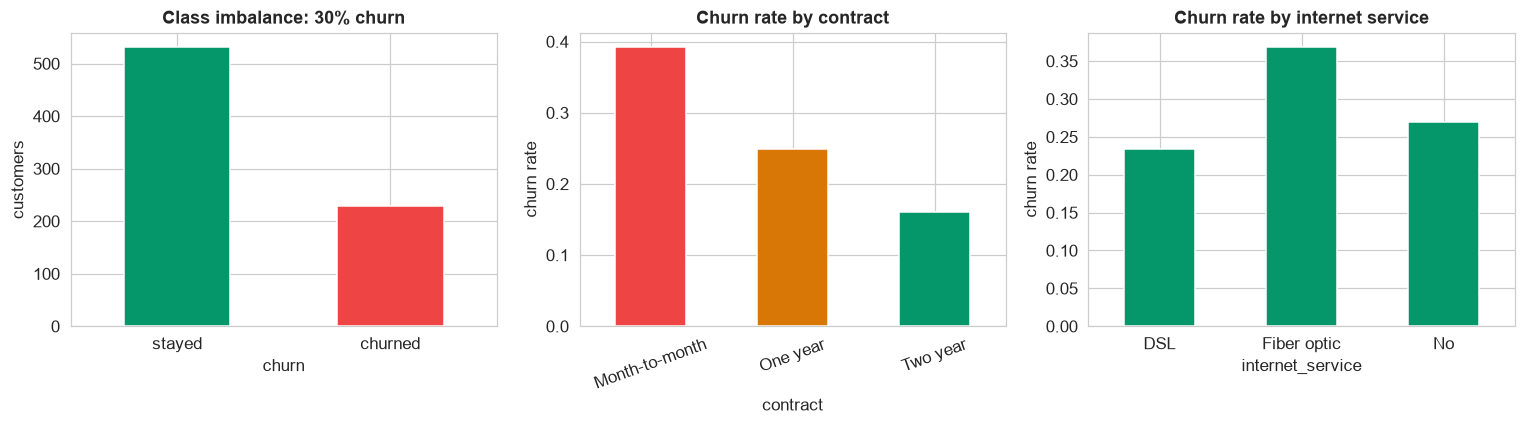

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14,4))
df.churn.value_counts().rename({0:'stayed',1:'churned'}).plot(kind='bar', color=[EM,RED], ax=ax[0])
ax[0].set(title=f'Class imbalance: {df.churn.mean():.0%} churn', ylabel='customers'); ax[0].tick_params(axis='x', rotation=0)
df.groupby('contract').churn.mean().reindex(['Month-to-month','One year','Two year']).plot(kind='bar', color=[RED,AMBER,EM], ax=ax[1])
ax[1].set(title='Churn rate by contract', ylabel='churn rate'); ax[1].tick_params(axis='x', rotation=20)
df.groupby('internet_service').churn.mean().plot(kind='bar', color=EM, ax=ax[2])
ax[2].set(title='Churn rate by internet service', ylabel='churn rate'); ax[2].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

Two things stand out. **The classes are imbalanced** (about 30% churn), so plain accuracy will be a misleading metric, a model that predicts 'nobody churns' would already score 70%. And **contract length is a huge signal**: month-to-month customers churn far more than those locked into one- or two-year contracts. Fiber-optic customers also churn more than DSL or no-internet. These previews tell us which predictors will matter.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 6 &#183; TRANSFORM FEATURES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Encode the categories a classifier can read</div>
<div style="color:#4a5578;margin-top:6px">Dummies for nominal fields, and a collinearity trap to avoid.</div>
</div>

Logistic regression needs numbers. `contract`, `internet_service`, and `payment_method` are *nominal*, so they become **dummy variables** (the formula's `C(...)` does this, one level held out as the reference). `senior_citizen` is already 0/1. One trap: `total_charges` is almost exactly `tenure_months` &#215; `monthly_charges`, so keeping all three creates **multicollinearity**, we will confirm with VIF in step 9 and drop the redundant one.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 7 &#183; ANALYZE PATTERNS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Churn rates and correlations</div>
<div style="color:#4a5578;margin-top:6px">Quantify what the pictures suggested.</div>
</div>

In [9]:
print('Churn rate by group:')
for col in ['contract','internet_service','payment_method','senior_citizen']:
    print(f'\n{col}:'); print((df.groupby(col).churn.mean()*100).round(1).astype(str) + '%')
print('\nNumeric correlation with churn:')
print(df[['tenure_months','monthly_charges','total_charges','churn']].corr()['churn'].round(2).to_string())

Churn rate by group:

contract:
contract
Month-to-month    39.3%
One year          24.9%
Two year          16.0%
Name: churn, dtype: str

internet_service:
internet_service
DSL            23.4%
Fiber optic    36.9%
No             26.9%
Name: churn, dtype: str

payment_method:
payment_method
Bank transfer       26.3%
Credit card         24.1%
Electronic check    32.1%
Mailed check        35.7%
Name: churn, dtype: str

senior_citizen:
senior_citizen
0    30.7%
1    27.4%
Name: churn, dtype: str

Numeric correlation with churn:
tenure_months     -0.35
monthly_charges    0.17
total_charges     -0.18
churn              1.00


Tenure is **negatively** correlated with churn (long-time customers stay), monthly charges **positively** (pricier plans leave more). Electronic-check payers and senior citizens churn a bit more. Now we have a clear hypothesis for the model to quantify.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 8 &#183; BUILD THE MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit a logistic regression</div>
<div style="color:#4a5578;margin-top:6px">One statsmodels call; the outcome is the log-odds of churn.</div>
</div>

In [10]:
model = smf.logit('churn ~ tenure_months + monthly_charges + C(contract) + C(internet_service)'
                  ' + C(payment_method) + senior_citizen + partner', df).fit(disp=0)
print(model.summary().tables[1])
print(f'\nMcFadden pseudo-R2 = {model.prsquared:.3f}')

                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                -0.6052      0.380     -1.594      0.111      -1.349       0.139
C(contract)[T.One year]                  -1.2361      0.233     -5.310      0.000      -1.692      -0.780
C(contract)[T.Two year]                  -1.6496      0.260     -6.341      0.000      -2.159      -1.140
C(internet_service)[T.Fiber optic]        1.1092      0.220      5.037      0.000       0.678       1.541
C(internet_service)[T.No]                 0.2706      0.259      1.043      0.297      -0.238       0.779
C(payment_method)[T.Credit card]         -0.2942      0.297     -0.991      0.322      -0.876       0.288
C(payment_method)[T.Electronic check]     0.3001      0.255      1.177      0.239      -0.199       0.800
C(payment_method)[T.Mailed check]         0.41

**Reading the table.** Each row is a coefficient on the **log-odds** scale (hard to feel directly, we exponentiate them into odds ratios in step 10). The `P>|z|` column flags which effects are real: contract, tenure, monthly charges, and fiber internet are strongly significant; payment method and senior status are not, once the others are controlled. Pseudo-R-squared (0.23) is the logistic analog of R-squared, but the real test of a classifier is its ranking and its errors, next.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 9 &#183; VALIDATE THE MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Ranking, errors, and the threshold</div>
<div style="color:#4a5578;margin-top:6px">AUC, confusion matrix, cross-validation, and the multicollinearity check.</div>
</div>

In [11]:
# (a) multicollinearity: total_charges is redundant (= tenure x monthly)
Xv = sm.add_constant(df[['tenure_months','monthly_charges','total_charges']].astype(float))
vif = pd.Series({c: variance_inflation_factor(Xv.values, i) for i,c in enumerate(Xv.columns)}).drop('const')
print('VIF:'); print(vif.round(1).to_string())
print('-> total_charges VIF ~9 (redundant), which is why we kept tenure and monthly separately and left it out.')

VIF:
tenure_months      6.3
monthly_charges    3.9
total_charges      9.0
-> total_charges VIF ~9 (redundant), which is why we kept tenure and monthly separately and left it out.


AUC = 0.809   5-fold cross-validated AUC = 0.794 (not overfit)


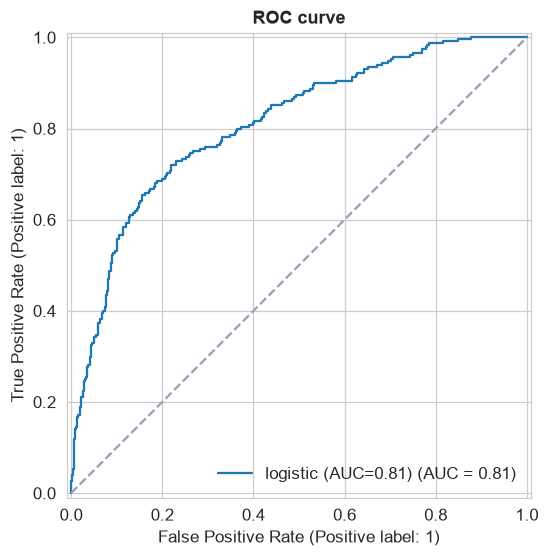

In [12]:
# (b) ranking quality: ROC / AUC, and honest out-of-sample AUC by cross-validation
p = model.predict(df); auc = roc_auc_score(df.churn, p)
Xd = pd.get_dummies(df[['tenure_months','monthly_charges','contract','internet_service','payment_method','senior_citizen','partner']], drop_first=True).astype(float)
cv = cross_val_score(LogisticRegression(max_iter=2000), Xd, df.churn, cv=5, scoring='roc_auc')
print(f'AUC = {auc:.3f}   5-fold cross-validated AUC = {cv.mean():.3f} (not overfit)')
fig, ax = plt.subplots(figsize=(5.6,5.2))
RocCurveDisplay.from_predictions(df.churn, p, ax=ax, name=f'logistic (AUC={auc:.2f})')
ax.plot([0,1],[0,1], ls='--', color=GREY); ax.set_title('ROC curve'); plt.tight_layout(); plt.show()

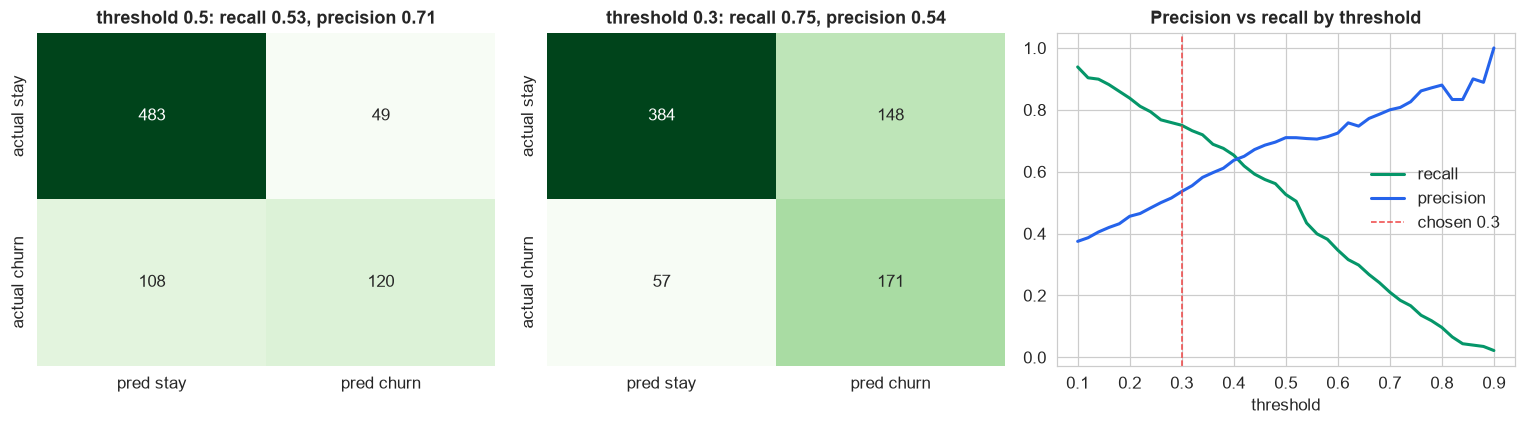

thr 0.5: acc 0.79 | precision 0.71 | recall 0.53
thr 0.3: acc 0.73 | precision 0.54 | recall 0.75


In [13]:
# (c) errors at two thresholds: confusion matrices + the precision/recall trade-off
fig, ax = plt.subplots(1, 3, figsize=(14,4))
for a, t in zip(ax[:2], (0.5, 0.3)):
    yhat = (p >= t).astype(int); cm = confusion_matrix(df.churn, yhat)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=a,
                xticklabels=['pred stay','pred churn'], yticklabels=['actual stay','actual churn'])
    a.set_title(f'threshold {t}: recall {recall_score(df.churn,yhat):.2f}, precision {precision_score(df.churn,yhat):.2f}')
ts = np.linspace(0.1, 0.9, 41)
recs = [recall_score(df.churn, p>=t) for t in ts]; precs = [precision_score(df.churn, p>=t, zero_division=0) for t in ts]
ax[2].plot(ts, recs, color=EM, lw=2, label='recall'); ax[2].plot(ts, precs, color=BLUE, lw=2, label='precision')
ax[2].axvline(0.3, color=RED, ls='--', lw=1, label='chosen 0.3'); ax[2].set(title='Precision vs recall by threshold', xlabel='threshold'); ax[2].legend()
plt.tight_layout(); plt.show()
for t in (0.5,0.3):
    yh=(p>=t).astype(int); print(f'thr {t}: acc {(yh==df.churn).mean():.2f} | precision {precision_score(df.churn,yh):.2f} | recall {recall_score(df.churn,yh):.2f}')

**Validation verdict.** `total_charges` had VIF ~9 (it *is* tenure times monthly charges), so excluding it was correct. The model **ranks** churners well (AUC 0.81), and the cross-validated AUC (0.79) is close, so it is not overfit. On errors: at the default 0.5 threshold the model catches only **53%** of churners, useless for a retention team. Because missing a churner costs more than a needless call, we **lower the threshold to 0.3**, which lifts recall to **75%** at the cost of more false alarms. Choosing that threshold is the whole point.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 10 &#183; INTERPRET THE RESULTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Odds ratios into retention actions</div>
<div style="color:#4a5578;margin-top:6px">Exponentiate each coefficient; below 1 protects, above 1 is a churn risk.</div>
</div>

In [14]:
OR = np.exp(model.params); ci = np.exp(model.conf_int())
tab = pd.DataFrame({'odds_ratio': OR.round(3), 'CI_low': ci[0].round(3), 'CI_high': ci[1].round(3)})
print(tab.to_string())
print(f"\nTwo-year vs month-to-month: OR = {OR['C(contract)[T.Two year]']:.2f}  (about {100*(1-OR['C(contract)[T.Two year]']):.0f}% lower churn odds)")
print(f"Each +12 months tenure    : OR = {np.exp(model.params['tenure_months']*12):.2f}")
print(f"Fiber optic vs DSL        : OR = {OR['C(internet_service)[T.Fiber optic]']:.2f}  (churn risk)")
print(f"Each +$10 monthly charge  : OR = {np.exp(model.params['monthly_charges']*10):.2f}")

                                       odds_ratio  CI_low  CI_high
Intercept                                   0.546   0.259    1.149
C(contract)[T.One year]                     0.291   0.184    0.458
C(contract)[T.Two year]                     0.192   0.115    0.320
C(internet_service)[T.Fiber optic]          3.032   1.969    4.668
C(internet_service)[T.No]                   1.311   0.788    2.179
C(payment_method)[T.Credit card]            0.745   0.416    1.333
C(payment_method)[T.Electronic check]       1.350   0.819    2.225
C(payment_method)[T.Mailed check]           1.521   0.896    2.581
partner[T.Yes]                              0.953   0.660    1.375
tenure_months                               0.954   0.945    0.963
monthly_charges                             1.019   1.012    1.025
senior_citizen                              0.754   0.484    1.176

Two-year vs month-to-month: OR = 0.19  (about 81% lower churn odds)
Each +12 months tenure    : OR = 0.57
Fiber optic vs DSL    

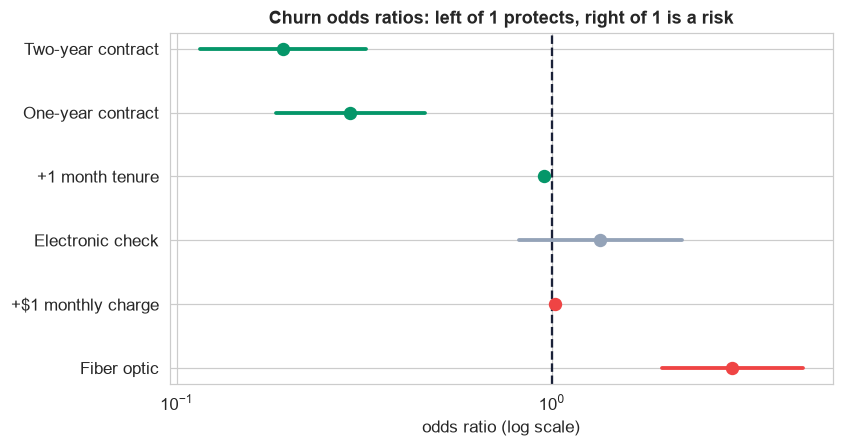

In [15]:
# Odds-ratio forest plot: which factors protect (OR<1) vs raise churn (OR>1)
terms = ['C(contract)[T.Two year]','C(contract)[T.One year]','tenure_months','C(payment_method)[T.Electronic check]','monthly_charges','C(internet_service)[T.Fiber optic]']
labels = ['Two-year contract','One-year contract','+1 month tenure','Electronic check','+$1 monthly charge','Fiber optic']
orr = np.exp(model.params[terms]); lo = np.exp(model.conf_int().loc[terms,0]); hi = np.exp(model.conf_int().loc[terms,1])
fig, ax = plt.subplots(figsize=(7.8,4.2)); yy = np.arange(len(terms))[::-1]
for i,t in enumerate(terms):
    col = GREEN if hi[t]<1 else (RED if lo[t]>1 else GREY)
    ax.plot([lo[t],hi[t]],[yy[i]]*2, color=col, lw=2.5); ax.scatter(orr[t], yy[i], color=col, s=60, zorder=3)
ax.axvline(1, color=INK, ls='--'); ax.set_xscale('log'); ax.set_yticks(yy); ax.set_yticklabels(labels)
ax.set(title='Churn odds ratios: left of 1 protects, right of 1 is a risk', xlabel='odds ratio (log scale)')
plt.tight_layout(); plt.show()

**What the model says.** **Contract length is the biggest lever**: a two-year contract carries about **80% lower** churn odds than month-to-month; a one-year contract about 70% lower. **Tenure protects** (each extra year cuts churn odds ~44%). On the risk side, **fiber-optic internet triples** churn odds versus DSL, and every extra $10 on the monthly bill raises them ~20%.

**Actionable retention plays.** (1) Move month-to-month customers onto annual contracts, the single highest-impact intervention. (2) Watch new, high-bill, fiber customers, the highest-risk profile, in their first year. (3) Target retention offers using the model's probability with the 0.3 threshold, so the team reaches three-quarters of would-be leavers.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 11 &#183; DEPLOY THE MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Score customers where the team works</div>
<div style="color:#4a5578;margin-top:6px">A risk score in the CRM, refreshed nightly.</div>
</div>

- **Persist** the fitted model and the cleaning steps as one `scikit-learn` Pipeline (`joblib.dump`), so a raw customer row is cleaned and scored identically every time.
- **Batch-score** every active customer nightly, writing a **churn probability** and a **risk flag** (probability above the chosen 0.3 threshold) back into the CRM for the retention team.
- **Tune the threshold to the economics**: if a retention offer costs a little and a lost customer costs a lot, a low threshold (high recall) is worth the extra false alarms; revisit it as those costs change.
- **Monitor** the churn base-rate and the model's precision/recall over time, and **retrain** each quarter as plans, prices, and competitors shift.
- **Guardrails**: report the probability, not just the flag, and log inputs for auditing and fairness review (a churn model must not simply proxy protected attributes).

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 12 &#183; THE PLAIN-ENGLISH WRITE-UP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">For the retention manager</div>
<div style="color:#4a5578;margin-top:6px">No jargon, just what to do Monday.</div>
</div>

**What we did.** We took an export of past customers, cleaned it up (removed duplicate records, fixed the many spellings of 'yes/no' and of the plan names, and turned a text 'total charges' field into real numbers), and built a formula that scores each customer's chance of leaving.

**How good is it?** Given two customers, the model correctly ranks the riskier one about **81 times out of 100** (that is the 'AUC'). Tested on customers it had not seen, it held up. Set to prioritize catching leavers, it flags about **three-quarters** of the customers who go on to churn.

**Who leaves, and what to do:**
1. **Month-to-month customers** are by far the most likely to leave. Getting them onto a one- or two-year contract cuts their churn risk by roughly **70-80%**, the biggest win available.
2. **Newer customers** and those on **higher monthly bills** or **fiber-optic** plans are higher risk, especially in the first year.
3. Use the score to build a weekly call list of the highest-risk customers and make them a retention offer.

**The honest caveats.** The model reflects *past* behavior and should be refreshed as prices and competitors change, and its risk score should support, not replace, a human judgment call.

**Bottom line: lock in month-to-month customers, and watch new high-bill fiber accounts.**

---
### The 12 steps, logistic edition
**1 Define** (predict churn, for retention) &#183; **2 Collect** (CRM/CSV/SQL) &#183; **3 Inspect** (find the messy labels) &#183; **4 Clean** (standardize the target's 8 spellings, the categories, and text charges) &#183; **5 Visualize** (imbalance + churn by group) &#183; **6 Transform** (dummy-encode categories) &#183; **7 Analyze** (churn rates + correlations) &#183; **8 Build** (logistic regression) &#183; **9 Validate** (VIF, AUC, cross-validation, confusion matrix, threshold) &#183; **10 Interpret** (odds ratios &#8594; retention plays) &#183; **11 Deploy** (nightly risk scores) &#183; **12 Communicate** (plain English). The same loop as the house-price study, tuned for a yes/no answer.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>